In [3]:
import pandas as pd

df_exchange = pd.read_excel('../data/exchange_rates.xlsx')
df_inflation = pd.read_excel('../data/inflation_rates.xlsx')

print("Exchange rate columns:", df_exchange.columns.tolist())
print("Exchange rate shape:", df_exchange.shape)
print()
print("Inflation rate columns:", df_inflation.columns.tolist())
print("Inflation rate shape:", df_inflation.shape)

Exchange rate columns: ['closingrate', 'ratedate', 'highestrate', 'lowestrate', 'weightedAvgRate', 'simpleAvgRate', 'noOfDeals', 'noOfDeals_InterBank', 'nfeM_Total_Turnover', 'interBank_Total_Turnover']
Exchange rate shape: (440, 10)

Inflation rate columns: ['tyear', 'tmonth', 'period', 'allItemsYearOn', 'allItemsAverage', 'foodYearOn', 'foodAverage', 'allItemsLessFrmProdYearOn', 'allItemsLessFrmProdAverage', 'allItemsLessFrmProdAndEnergyYearOn', 'allItemsLessFrmProdAndEnergyAvg']
Inflation rate shape: (283, 11)


In [5]:
df_inflation.head()

,tyear,tmonth,period,allItemsYearOn,allItemsAverage,foodYearOn,foodAverage,allItemsLessFrmProdYearOn,allItemsLessFrmProdAverage,allItemsLessFrmProdAndEnergyYearOn,allItemsLessFrmProdAndEnergyAvg
0,2026,7,July 2026,15.43,16.89,20.31,16.06,14.08,17.45,14.97,18.09
1,2026,6,June 2026,15.91,17.63,17.52,16.42,15.41,18.25,15.92,18.82
2,2026,5,May 2026,15.93,18.36,16.96,16.99,15.77,19.02,16.82,19.59
3,2026,4,April 2026,15.69,19.16,16.06,17.55,14.77,19.84,15.86,20.24
4,2026,3,March 2026,15.38,20.05,14.31,18.21,15.66,20.86,16.21,21.09


In [4]:
df_exchange.head()

,closingrate,ratedate,highestrate,lowestrate,weightedAvgRate,simpleAvgRate,noOfDeals,noOfDeals_InterBank,nfeM_Total_Turnover,interBank_Total_Turnover
0,1322.5,September-04-2026,1324.0,1319.45,1321.2160,1321.0693,0,98.0,0.000000e+00,1.138815e+08
1,1322.5,September-03-2026,1324.0,1302.00,1315.6717,1315.7944,385,153.0,6.743824e+08,1.520428e+08
2,1324.5,September-02-2026,1336.0,1323.00,1326.6862,1326.2774,310,105.0,6.584628e+08,9.365576e+07
3,1329.0,September-01-2026,1335.5,1327.00,1329.4300,1329.6763,347,139.0,5.744193e+08,1.394546e+08
4,1335.5,August-31-2026,1343.0,1320.00,1332.9396,1333.2198,279,118.0,2.285215e+08,1.066434e+08


In [6]:
df_exchange['ratedate'] = pd.to_datetime(df_exchange['ratedate'], format='%B-%d-%Y')
df_exchange = df_exchange.sort_values('ratedate').reset_index(drop=True)
df_exchange[['ratedate', 'closingrate']].head()

,ratedate,closingrate
0,2024-12-02,1660.0
1,2024-12-03,1625.0
2,2024-12-04,1608.0
3,2024-12-05,1567.0
4,2024-12-06,1535.0


In [7]:
df_inflation['date'] = pd.to_datetime(df_inflation['tyear'].astype(str) + '-' + df_inflation['tmonth'].astype(str) + '-01')
df_inflation = df_inflation.sort_values('date').reset_index(drop=True)
df_inflation[['date', 'allItemsYearOn']].head()

,date,allItemsYearOn
0,2003-01-01,10.6
1,2003-02-01,7.3
2,2003-03-01,5.9
3,2003-04-01,8.3
4,2003-05-01,8.7


In [9]:
print("Exchange rate range:", df_exchange['ratedate'].min(), "to", df_exchange['ratedate'].max())
print("inflation rage:", df_inflation['date'].min(), "to", df_inflation['date'].max())

Exchange rate range: 2024-12-02 00:00:00 to 2026-09-04 00:00:00
inflation rage: 2003-01-01 00:00:00 to 2026-07-01 00:00:00


In [10]:
df_exchange_monthly = df_exchange.set_index('ratedate').resample('MS').agg({
    'closingrate': 'mean',
    'highestrate': 'max',
    'lowestrate': 'min',
    'weightedAvgRate': 'mean'
}).reset_index()

df_exchange_monthly = df_exchange_monthly.rename(columns={'ratedate': 'date'})
df_exchange_monthly.head()

,date,closingrate,highestrate,lowestrate,weightedAvgRate
0,2024-12-01,1553.725000,1678.0,1500.0,1553.729580
1,2025-01-01,1536.454545,1565.0,1440.0,1535.946200
2,2025-02-01,1504.134783,1520.0,1480.0,1500.697630
3,2025-03-01,1533.000000,1615.0,1480.0,1526.369885
4,2025-04-01,1602.789474,1655.0,1500.0,1595.051605


In [11]:
df_combined = pd.merge(
    df_exchange_monthly,
    df_inflation[['date', 'allItemsYearOn', 'foodYearOn']],
    on='date',
    how='inner'
)

df_combined.head()

,date,closingrate,highestrate,lowestrate,weightedAvgRate,allItemsYearOn,foodYearOn
0,2024-12-01,1553.725000,1678.0,1500.0,1553.729580,34.80,39.84
1,2025-01-01,1536.454545,1565.0,1440.0,1535.946200,27.61,29.63
2,2025-02-01,1504.134783,1520.0,1480.0,1500.697630,26.27,26.98
3,2025-03-01,1533.000000,1615.0,1480.0,1526.369885,27.35,25.22
4,2025-04-01,1602.789474,1655.0,1500.0,1595.051605,26.82,24.68


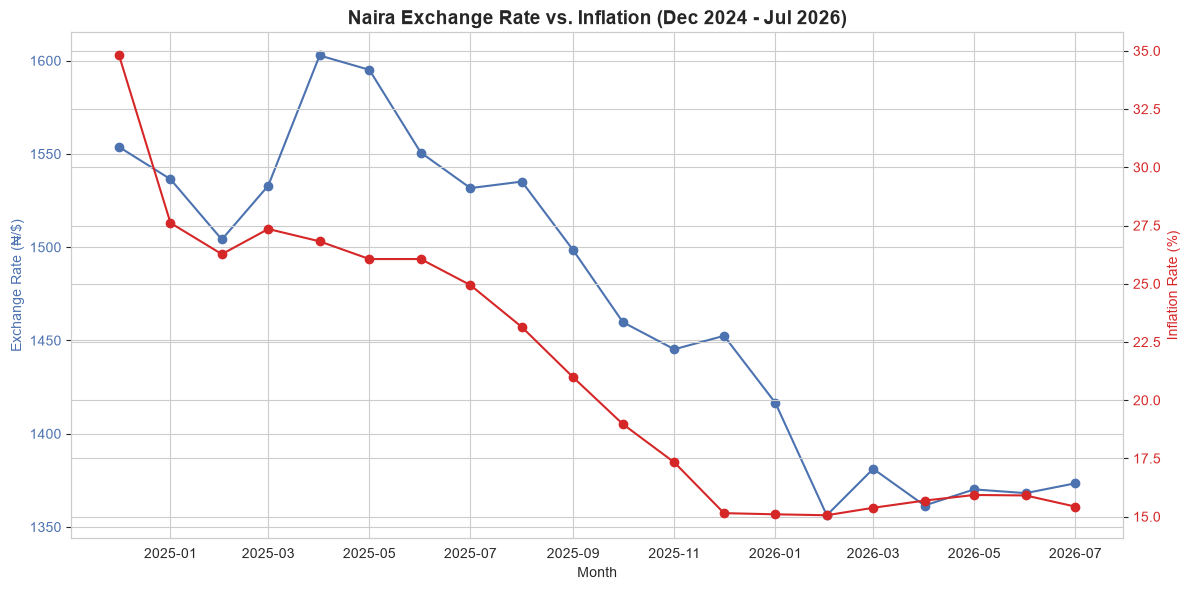

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_combined['date'], df_combined['closingrate'], color='#4C72B0', marker='o', label='Exchange Rate')
ax1.set_xlabel('Month')
ax1.set_ylabel('Exchange Rate (₦/$)', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(df_combined['date'], df_combined['allItemsYearOn'], color='#d62728', marker='o', label='Inflation (YoY %)')
ax2.set_ylabel('Inflation Rate (%)', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

plt.title('Naira Exchange Rate vs. Inflation (Dec 2024 - Jul 2026)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
fig.tight_layout()
plt.savefig('../images/exchange_vs_inflation.png', dpi=150)
plt.show();


In [13]:
correlation = df_combined['closingrate'].corr(df_combined['allItemsYearOn'])
print(f"Correlation between exchange rate and inflation: {correlation:.3f}")

Correlation between exchange rate and inflation: 0.874


In [15]:
correlation_food = df_combined['closingrate'].corr(df_combined['foodYearOn'])
print(f"Correlation between exchange rate and food inflation: {correlation_food:.3f}")
print(f"Correlation between exchange rate and headline inflation: {correlation:.3f}")

Correlation between exchange rate and food inflation: 0.714
Correlation between exchange rate and headline inflation: 0.874


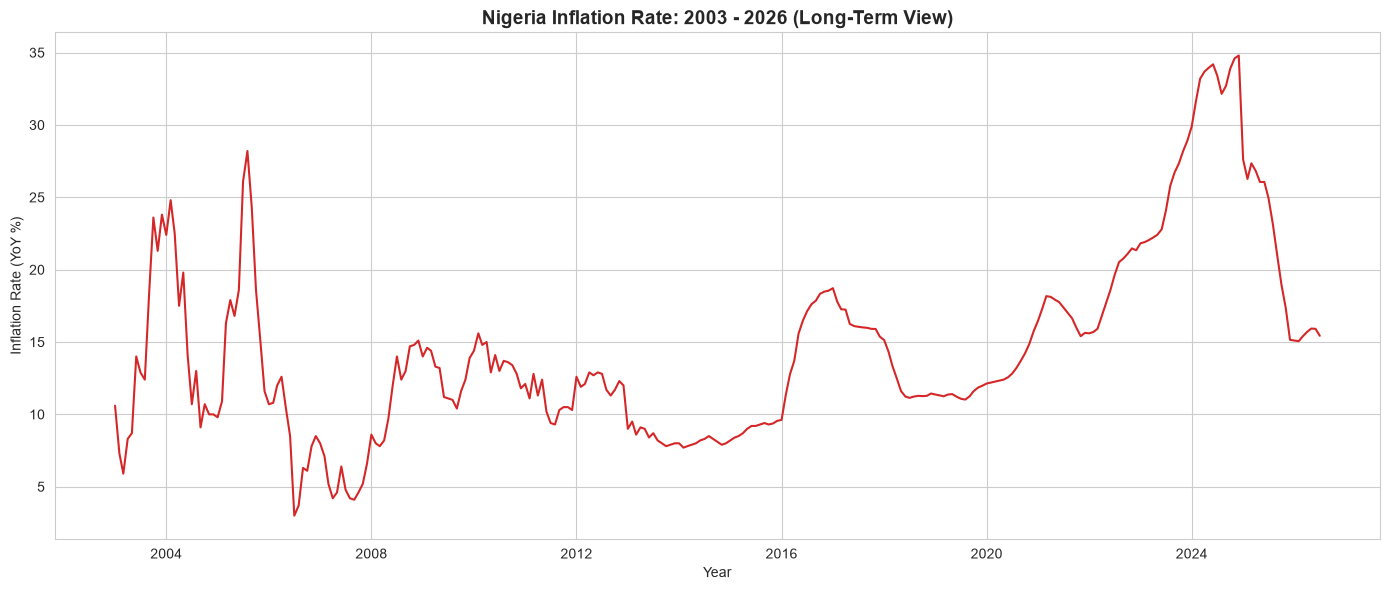

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_inflation['date'], df_inflation['allItemsYearOn'], color='#d62728', linewidth=1.5)
ax.set_title('Nigeria Inflation Rate: 2003 - 2026 (Long-Term View)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation Rate (YoY %)')
plt.tight_layout()
plt.savefig('../images/long_term_inflation.png', dpi=150)
plt.show();

In [21]:
df_combined['exchange_rate_prev_month'] = df_combined['closingrate'].shift(1)
lag_correlation = df_combined['exchange_rate_prev_month'].corr(df_combined['allItemsYearOn'])
print(f"Correlation between PREVIOUS month's exchange rate and CURRENT inflation: {lag_correlation:.3f}")

Correlation between PREVIOUS month's exchange rate and CURRENT inflation: 0.867
